In [1]:
import numpy as np
import matplotlib.pyplot as plt
from backgrounds import StochasticBackgroundResponse, utils, signal
from lisaorbits import KeplerianOrbits
import healpy as hp
import os
import jax
import matplotlib.colors as mcolors
import h5py

jax.config.update("jax_enable_x64", True)


In [2]:
np.random.seed(1)
#LISA noise:
atm=3e-15
aoms=15e-12
pi=np.pi
c=299792458
sin=np.sin
def sin2(x):
    return (np.sin(x))**2

cos=np.cos
L=2.5e9

dt = 2.0  # Sampling interval (seconds)
fs = 1.0 / dt
Tobs_days = 365.25
a_day = 24 * 3600
tot_time = Tobs_days * a_day
Tobs = Tobs_days / 365.25 #in years
f0=3.16e-3#Pivot freq

dire = "/home/naim769/oneMonth/pcode/second/papernotebooksandcode"
h5f = h5py.File(f"{dire}/sim_inputs.h5", "r")

f = h5f["f"][:]
tdi_response = h5f["tdi_response"][:]

In [3]:
#signal to noise ratio:
def _const(a,b,n):
    return (a-b)/n

def _squaredratio(a,b):
    return ((a)**2)/((b)**2)

def computesnr(psd_signal, psd_noise, upper, lower, T_sec):  # note use PSD not log PSD
    """
    Calculates the SNR for a Stochastic GW Background  (A and E channels and assuming A=E) based on arXiv:1908.00546 (mid-point rule approximation for the integral).
    """
    return np.sqrt(2)*np.sqrt(T_sec* sum(_squaredratio(psd_signal,psd_noise)) * _const(a=upper,b=lower,n=len(psd_signal)))


# LISA noise:
def testmass_psd(atm, f):
    '''
    Testmass theoretical spectrum
    :param atm: testmass parameter
    :param f: frequencies
    :return: testmass PSD
    '''
    f = np.asarray(f, float)
    f = np.clip(f, 1e-12, None)  # dividing by zero
    return (atm)**2 * (1 + (0.4e-3/f)**2) * (1 + (f/8e-3)**4) * (1/(2*pi*f*c))**2

def oms_psd(aoms, f):
    '''
    OMS theoretical spectrum
    :param aoms: OMS parameter
    :param f: frequencies
    :return: OMS PSD
    '''
    f = np.asarray(f, float)
    f = np.clip(f, 1e-12, None) #dividing by zero
    return (aoms)**2 * (1 + (2e-3/f)**4) * (2*pi*f/c)**2

def x_phase(f, L=L, c=c):
    return 2.0 * np.pi * f * (L / c)

def common(f):
    x = x_phase(f)
    return 16.0 * (np.sin(x)**2) * (np.sin(2.0*x)**2)

def A_psd(atm, aoms, f):
    '''
    Theoretical noise spectrum of TDI A channel (Assuming same for E channel)
    :param atm: testmass parameter
    :param aoms: oms parameter
    :param f: frequencies
    :return: TDI A PSD
    '''
    x = x_phase(f)
    tm = 4.0 * common(f) * (3.0 + 2.0*np.cos(x) + np.cos(2.0*x)) * testmass_psd(atm, f)
    om = 2.0 * common(f) * (2.0 + np.cos(x)) * oms_psd(aoms, f)
    return tm + om

def T_psd(atm, aoms, f):
    '''
    Theoretical spectrum of TDI T channel (assuming no signal component in this channel)
    :param atm: testmass parameter
    :param aoms: oms parameter
    :param f: frequencies
    :return: TDI T PSD
    '''

    x = x_phase(f)
    tm = 32.0 * common(f) * (np.sin(0.5*x)**4) * testmass_psd(atm, f)
    om = 4.0 * common(f) * (1.0 - np.cos(x)) * oms_psd(aoms, f)
    return tm + om

#SGWB function (power law)
def sgwb_gen_fun(f_fit,n,f0,Omega0,tdi_response):
    '''
    Stochastic gravitational wave background (SGWB) PSD function (power law)
    This code is taken from https://qbaghi.pages.in2p3.fr/backgrounds/notebooks/sgwb-response.html by Quentin Baghi
    :param f_fit: frequencies
    :param n: power
    :param f0: pivot frequency (known: 10^-3)
    :param Omega0: amplitude
    :param tdi_response: LISA GW response matrix (known)
    :return: SGWB PSD
    '''
    s_h = signal.sgwb_psd(f_fit, spec_index=n, freq0=f0, omega_gw=Omega0)
    tdi_covariance = (tdi_response.T * s_h).T
    sig_A_spec=abs(tdi_covariance[:, 0, 0])
    return sig_A_spec



In [4]:
#defining the grid of parameters (20x30):
omega_min, omega_max = 1e-15, 5e-12
n_min, n_max = -3.0, 3.0
num_pts = 20
num_pts_n=30
omega_vals = np.geomspace(omega_min, omega_max, num_pts)
n_vals = np.linspace(n_min, n_max, num_pts_n)

param_combinations = np.array([[n, om] for n in n_vals for om in omega_vals])

print(f"Grid generated with {len(param_combinations)} points. Total Array range: 0-{len(param_combinations)-1}")

Grid generated with 600 points. Total Array range: 0-599


In [5]:
SA = A_psd(atm, aoms, f)
ST = T_psd(atm, aoms, f)

In [6]:

all_signals = []
snr_results = []
for n, omega in param_combinations:
    sig_A = sgwb_gen_fun(f_fit=f, n=n, f0=f0, Omega0=omega, tdi_response=tdi_response)

    all_signals.append(sig_A)

    snr = computesnr(
        psd_signal=sig_A,
        psd_noise=SA,
        upper=f[-1],
        lower=f[0],
        T_sec=tot_time
    )
    snr_results.append(snr)

snr_grid = np.array(snr_results).reshape(num_pts_n, num_pts)
all_signals = np.array(all_signals)



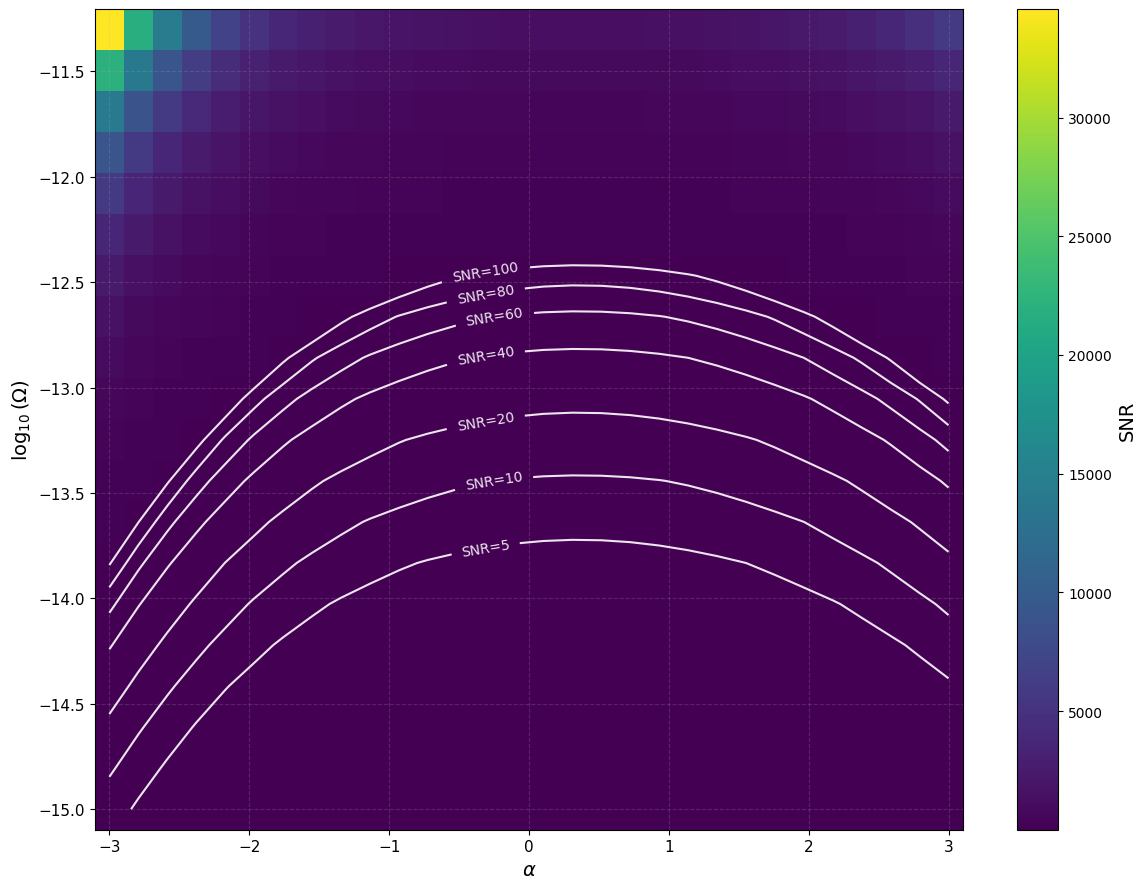

In [7]:
x = n_vals
y = np.log10(omega_vals)
X, Y = np.meshgrid(x, y)
Z_SNR = snr_grid.T

plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 9))

# Heatmap for SNR
im = ax.pcolormesh(x, y, Z_SNR,
                   cmap='viridis',
                   shading='auto')
cb = fig.colorbar(im, ax=ax)
cb.set_label('SNR', fontsize=14)

# SNR Contours
snr_levels = [5, 10, 20, 40, 60, 80, 100]
contours = ax.contour(x, y, Z_SNR, levels=snr_levels, colors='white', linewidths=1.5, alpha=0.9)
ax.clabel(contours, inline=True, fontsize=10, fmt='SNR=%.0f')
ax.set_xlabel(r'$\alpha$', fontsize=14)
ax.set_ylabel(r'$\log_{10}(\Omega)$', fontsize=14)

ax.tick_params(axis='both', which='major', labelsize=11)
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.tight_layout()
plt.show()

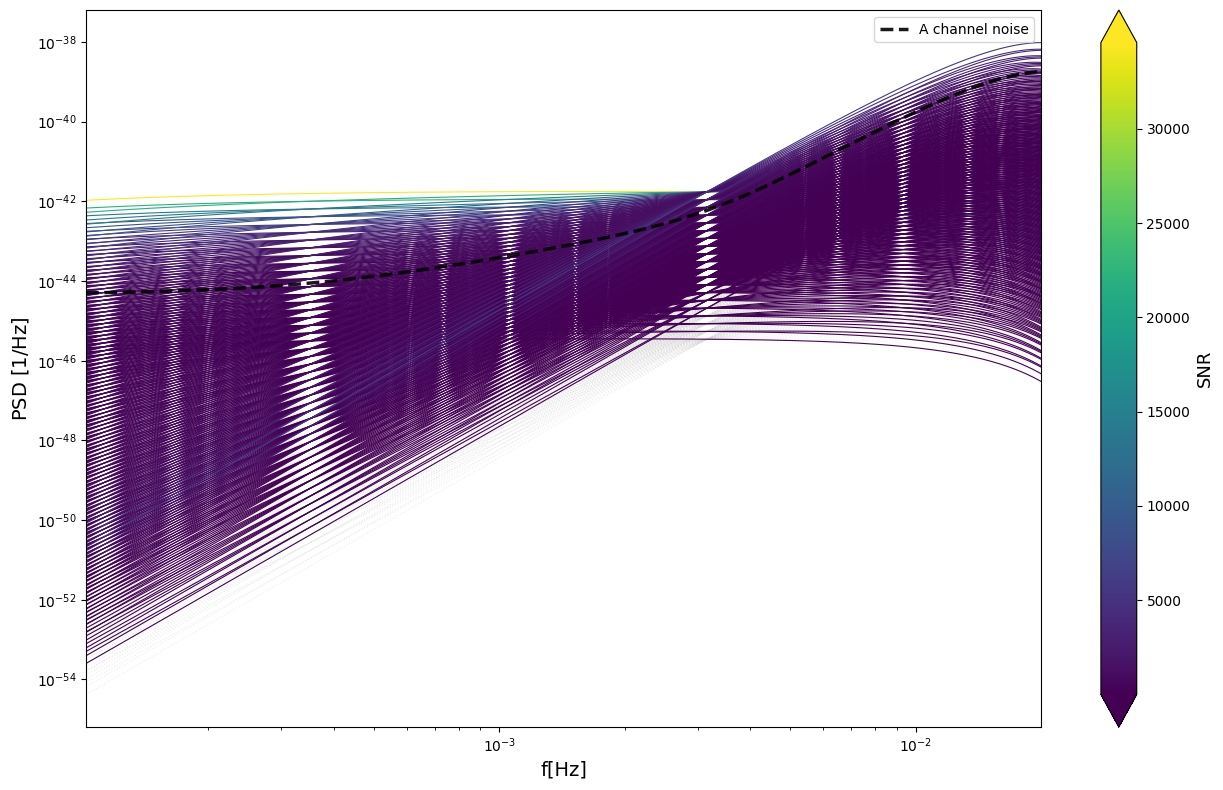

In [8]:
plt.style.use('default')
snr_array = np.array(snr_results)

snr_min = snr_array.min()
snr_max = snr_array.max()

norm = mcolors.Normalize(vmin=snr_min, vmax=snr_max)
cmap = plt.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(13, 8))

#A channel noise
ax.loglog(f, SA, color='black', linestyle='--', linewidth=2.5,
          label='A channel noise', alpha=0.9, zorder=5)



for sig_A, snr_val in zip(all_signals, snr_array):
    if snr_val <= 5:
        line_color = 'lightgray'
        alpha_val = 0.4
        z_order = 1
        linesty=':'
    else:
        line_color = cmap(norm(snr_val))
        alpha_val = 1
        z_order = 2
        linesty='-'

    ax.loglog(f, sig_A, color=line_color, alpha=alpha_val,
              linewidth=0.8, zorder=z_order,linestyle=linesty)

ax.set_xlabel('f[Hz]', fontsize=14)
ax.set_ylabel(r'PSD $[1/\text{Hz}]$', fontsize=14)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, extend='both')
cbar.set_label(f'SNR', fontsize=13)

ax.set_xlim(f.min(), f.max())
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()